In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

gxl = pd.read_csv("../data/gxl_historical.csv")
fin_df = pd.read_csv("../data/financials.csv")
prices = pd.read_csv("../data/prices.csv")

print("Datos cargados OK")
print(gxl.to_string(index=False))

Datos cargados OK
 year  revenue  ebitda_adj  ebit_adj  net_income  capex  net_debt  ebitda_margin  revenue_growth
 2019   1351.0       280.0     175.0        88.0  145.0     980.0           20.7             NaN
 2020   1384.5       305.0     195.0        95.0  162.0     950.0           22.0             2.5
 2021   1510.0       342.0     220.0       115.0  195.0    1100.0           22.6             9.1
 2022   1820.0       410.0     265.0       138.0  230.0    1350.0           22.5            20.5
 2023   1969.0       498.0     320.0       158.0  285.0    1420.0           25.3             8.2


In [2]:
gxl["ebitda_margin"]  = (gxl["ebitda_adj"] / gxl["revenue"] * 100).round(1)
gxl["ebit_margin"]    = (gxl["ebit_adj"]   / gxl["revenue"] * 100).round(1)
gxl["net_margin"]     = (gxl["net_income"]  / gxl["revenue"] * 100).round(1)
gxl["capex_intensity"]= (gxl["capex"]       / gxl["revenue"] * 100).round(1)
gxl["net_debt_ebitda"]= (gxl["net_debt"]    / gxl["ebitda_adj"]).round(2)

print("KPI Ratios:")
print(gxl[["year", "ebitda_margin", "ebit_margin",
           "net_margin", "capex_intensity", "net_debt_ebitda"]].to_string(index=False))

KPI Ratios:
 year  ebitda_margin  ebit_margin  net_margin  capex_intensity  net_debt_ebitda
 2019           20.7         13.0         6.5             10.7             3.50
 2020           22.0         14.1         6.9             11.7             3.11
 2021           22.6         14.6         7.6             12.9             3.22
 2022           22.5         14.6         7.6             12.6             3.29
 2023           25.3         16.3         8.0             14.5             2.85


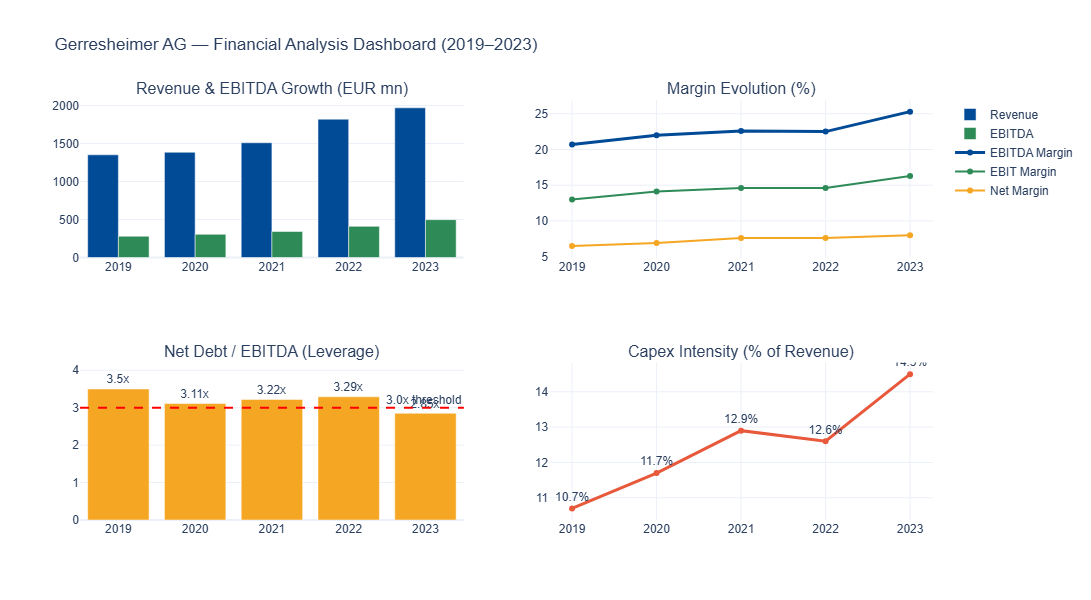

In [3]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=(
        "Revenue & EBITDA Growth (EUR mn)",
        "Margin Evolution (%)",
        "Net Debt / EBITDA (Leverage)",
        "Capex Intensity (% of Revenue)"
    ))

# 1. Revenue & EBITDA
fig.add_trace(go.Bar(
    x=gxl["year"], y=gxl["revenue"],
    name="Revenue", marker_color="#004A96",
    showlegend=True
), row=1, col=1)

fig.add_trace(go.Bar(
    x=gxl["year"], y=gxl["ebitda_adj"],
    name="EBITDA", marker_color="#2E8B57",
    showlegend=True
), row=1, col=1)

# 2. Margins
fig.add_trace(go.Scatter(
    x=gxl["year"], y=gxl["ebitda_margin"],
    name="EBITDA Margin", mode="lines+markers",
    line=dict(color="#004A96", width=3)
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=gxl["year"], y=gxl["ebit_margin"],
    name="EBIT Margin", mode="lines+markers",
    line=dict(color="#2E8B57", width=2)
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=gxl["year"], y=gxl["net_margin"],
    name="Net Margin", mode="lines+markers",
    line=dict(color="#F5A623", width=2)
), row=1, col=2)

# 3. Leverage
colors_lev = ["#E8593C" if v > 3.5 else "#F5A623" if v > 2.5 else "#2E8B57"
              for v in gxl["net_debt_ebitda"]]

fig.add_trace(go.Bar(
    x=gxl["year"], y=gxl["net_debt_ebitda"],
    marker_color=colors_lev,
    showlegend=False,
    text=gxl["net_debt_ebitda"].astype(str) + "x",
    textposition="outside"
), row=2, col=1)

fig.add_hline(y=3.0, line_dash="dash", line_color="red",
              annotation_text="3.0x threshold", row=2, col=1)

# 4. Capex intensity
fig.add_trace(go.Scatter(
    x=gxl["year"], y=gxl["capex_intensity"],
    mode="lines+markers+text",
    text=gxl["capex_intensity"].astype(str) + "%",
    textposition="top center",
    line=dict(color="#E8593C", width=3),
    showlegend=False
), row=2, col=2)

fig.update_layout(
    title="Gerresheimer AG — Financial Analysis Dashboard (2019–2023)",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=600,
    barmode="group"
)

fig.show()

In [4]:
print("=" * 55)
print("GERRESHEIMER AG — FINANCIAL HEALTH ASSESSMENT")
print("=" * 55)

latest = gxl.iloc[-1]
prev   = gxl.iloc[-2]

print(f"""
GREEN FLAGS ✓
  Revenue CAGR 2019–2023:    {((latest['revenue']/gxl.iloc[0]['revenue'])**(1/4)-1)*100:.1f}%
  EBITDA margin improvement: {gxl.iloc[0]['ebitda_margin']:.1f}% → {latest['ebitda_margin']:.1f}% (+{latest['ebitda_margin']-gxl.iloc[0]['ebitda_margin']:.1f}pp)
  Revenue growth 2023:       +{latest['revenue_growth']:.1f}%
  Net income growth 2023:    +{((latest['net_income']/prev['net_income'])-1)*100:.1f}%
  Formula G transformation:  On track (margin expansion confirmed)

RED FLAGS ✗
  Net Debt/EBITDA 2023:      {latest['net_debt_ebitda']:.2f}x  (threshold: 3.0x)
  Capex intensity 2023:      {latest['capex_intensity']:.1f}%  (high but justified by growth)
  Net debt absolute:         EUR {latest['net_debt']:.0f}mn (elevated)

OVERALL ASSESSMENT
  Gerresheimer shows strong operational momentum with consistent
  margin expansion. Leverage is elevated but manageable given
  the EBITDA growth trajectory. The transformation from commodity
  packaging to high-margin drug delivery systems is the key
  value driver for any potential acquirer.
""")
print("=" * 55)

GERRESHEIMER AG — FINANCIAL HEALTH ASSESSMENT

GREEN FLAGS ✓
  Revenue CAGR 2019–2023:    9.9%
  EBITDA margin improvement: 20.7% → 25.3% (+4.6pp)
  Revenue growth 2023:       +8.2%
  Net income growth 2023:    +14.5%
  Formula G transformation:  On track (margin expansion confirmed)

RED FLAGS ✗
  Net Debt/EBITDA 2023:      2.85x  (threshold: 3.0x)
  Capex intensity 2023:      14.5%  (high but justified by growth)
  Net debt absolute:         EUR 1420mn (elevated)

OVERALL ASSESSMENT
  Gerresheimer shows strong operational momentum with consistent
  margin expansion. Leverage is elevated but manageable given
  the EBITDA growth trajectory. The transformation from commodity
  packaging to high-margin drug delivery systems is the key
  value driver for any potential acquirer.



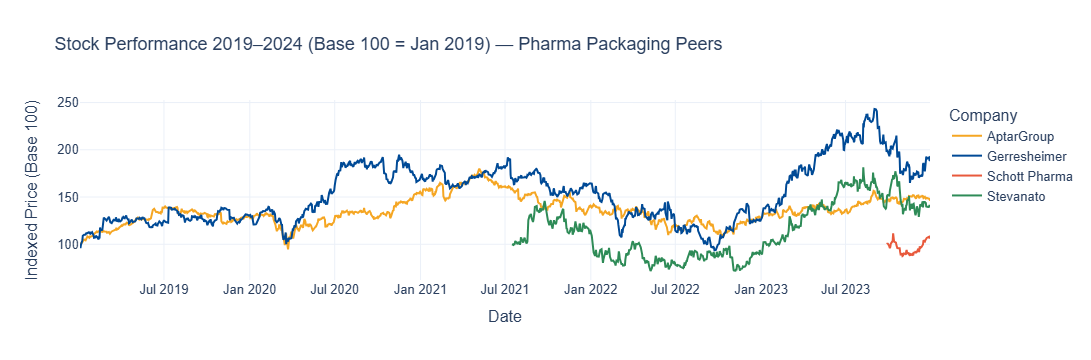

In [5]:
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["company", "date"])

base = prices.groupby("company").first()["close"]
prices["close_norm"] = prices.apply(
    lambda r: r["close"] / base[r["company"]] * 100, axis=1
)

fig2 = go.Figure()

colors_map = {
    "Gerresheimer":  "#004A96",
    "Schott Pharma": "#E8593C",
    "Stevanato":     "#2E8B57",
    "AptarGroup":    "#F5A623"
}

for company in prices["company"].unique():
    subset = prices[prices["company"] == company]
    fig2.add_trace(go.Scatter(
        x=subset["date"],
        y=subset["close_norm"],
        name=company,
        mode="lines",
        line=dict(color=colors_map.get(company, "gray"), width=2)
    ))

fig2.update_layout(
    title="Stock Performance 2019–2024 (Base 100 = Jan 2019) — Pharma Packaging Peers",
    xaxis_title="Date",
    yaxis_title="Indexed Price (Base 100)",
    template="plotly_white",
    font=dict(family="Arial", size=13),
    hovermode="x unified",
    legend_title="Company"
)

fig2.show()

In [6]:
gxl.to_csv("../data/gxl_ratios.csv", index=False)
print("Guardado OK")

Guardado OK
